Available columns: ['averageInteractionsPerCrossing', 'p_Rhad1', 'p_Rhad', 'p_f3', 'p_weta2', 'p_Rphi', 'p_Reta', 'p_Eratio', 'p_f1', 'p_TRTPID']

Energy-related columns: ['pX_core57cellsEnergyCorrection', 'pX_maxEcell_energy', 'pX_neflowisolcoreConeEnergyCorrection', 'pX_topoetconecoreConeEnergyCorrection', 'p_Truth_Energy']
Electron-related columns: ['p_Truth_isElectron']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29461
[LightGBM] [Info] Number of data points in the train set: 30240, number of used features: 132
[LightGBM] [Info] Start training from score 64051.910949
Train R²: 0.9811
Validation R²: 0.9095
Train RMSE: 7734.5439
Validation RMSE: 16805.0422


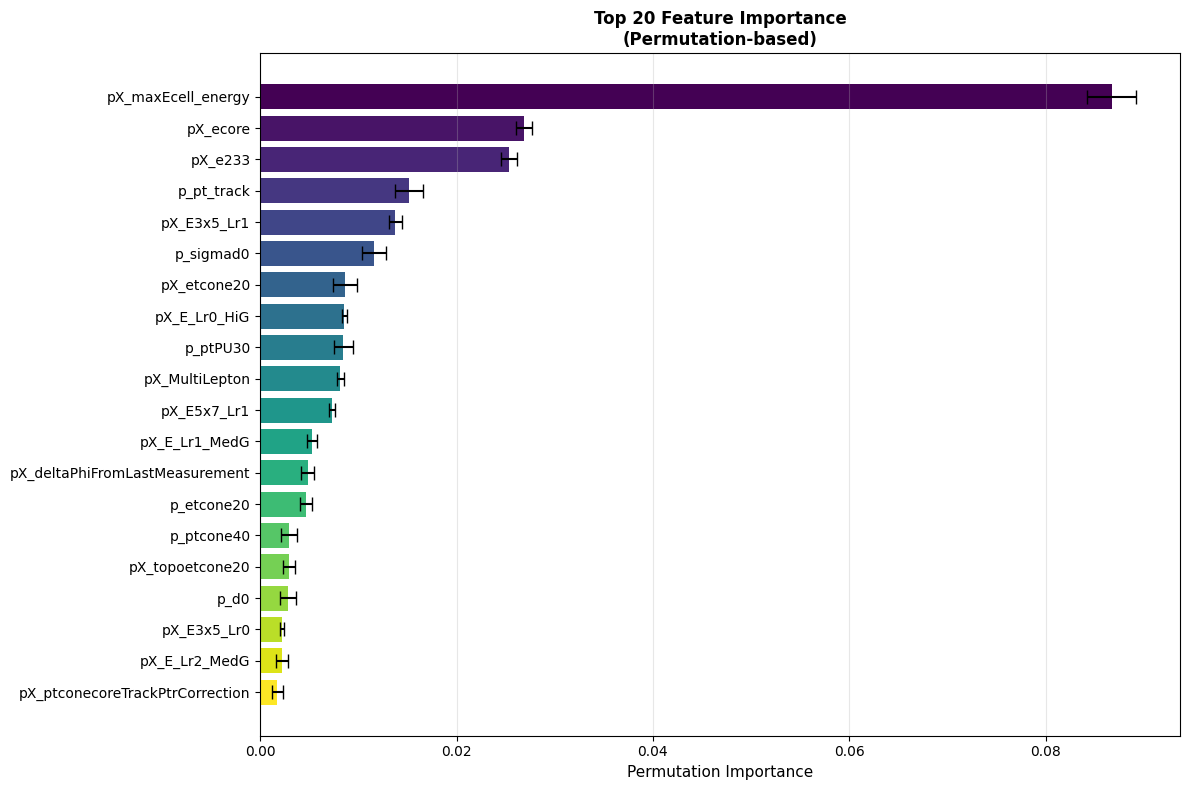

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor

# --- Data Loading and Initial Prep ---
reg_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')

# Check column names
print("Available columns:", reg_train_data.columns.tolist()[:10])
print("\nEnergy-related columns:", [col for col in reg_train_data.columns if 'energy' in col.lower()])
print("Electron-related columns:", [col for col in reg_train_data.columns if 'electron' in col.lower()])

# Filter for electrons only
electrons_mask = reg_train_data['p_Truth_isElectron'] == 1
reg_train_electrons = reg_train_data[electrons_mask].copy()

# Use the correct energy column name
energy_col = 'p_Truth_Energy' if 'p_Truth_Energy' in reg_train_electrons.columns else 'p_truth_Energy'
target = reg_train_electrons[energy_col]
variables = reg_train_electrons.drop(columns=['p_Truth_isElectron', energy_col])

reg_test_data = pd.read_csv('../Data/AppML_InitialProject_test_regression.csv')

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42
)

model = LGBMRegressor(
    n_estimators = 289,
    max_depth = 10,
    learning_rate = 0.085,
    subsample = 0.78,
    colsample_bytree = 0.56,
    min_child_weight = 7,
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train, y_train)

# Evaluate on validation set
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_val, val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print(f'Train R²: {train_r2:.4f}')
print(f'Validation R²: {val_r2:.4f}')
print(f'Train RMSE: {train_rmse:.4f}')
print(f'Validation RMSE: {val_rmse:.4f}')

# Calculate permutation importance on validation set
perm_importance = permutation_importance(
    model, X_val, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create results dataframe
importance_df = pd.DataFrame({
    'feature': variables.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Bar plot
top_n = 20
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Permutation-based)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

In [29]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = LGBMRegressor(
    n_estimators = 289,
    max_depth = 10,
    learning_rate = 0.085,
    subsample = 0.78,
    colsample_bytree = 0.56,
    min_child_weight = 7,
    random_state = 42,
    n_jobs = -1
)

model_top.fit(X_train_top, y_train)
train_pred_top = model_top.predict(X_train_top)
val_pred_top = model_top.predict(X_val_top)
train_r2_top = r2_score(y_train, train_pred_top)
val_r2_top = r2_score(y_val, val_pred_top)

print(f'Train R² with top features: {train_r2_top:.4f}')
print(f'Validation R² with top features: {val_r2_top:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 30240, number of used features: 20
[LightGBM] [Info] Start training from score 64051.910949
Train R² with top features: 0.9696
Validation R² with top features: 0.9127


In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for LightGBM on the reduced 15-feature set
param_distributions = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_pred_tuned = best_model.predict(X_val_top)
val_r2_tuned = r2_score(y_val, val_pred_tuned)
val_mae_tuned = mean_absolute_error(y_val, val_pred_tuned)
val_rmse_tuned = np.sqrt(mean_squared_error(y_val, val_pred_tuned))
print(f'Validation R² after tuning: {val_r2_tuned:.4f}')
print(f'Validation MAE after tuning: {val_mae_tuned:.4f}')
print(f'Validation RMSE after tuning: {val_rmse_tuned:.4f}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 30240, number of used features: 20
[LightGBM] [Info] Start training from score 64051.910949
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [31]:

best_model = random_search.best_estimator_
val_pred_tuned = best_model.predict(X_val_top)
val_r2_tuned = r2_score(y_val, val_pred_tuned)
val_mae_tuned = mean_absolute_error(y_val, val_pred_tuned)
val_rmse_tuned = np.sqrt(mean_squared_error(y_val, val_pred_tuned))
print(f'Validation R² after tuning: {val_r2_tuned:.4f}')
print(f'Validation MAE after tuning: {val_mae_tuned:.4f}')
print(f'Validation RMSE after tuning: {val_rmse_tuned:.4f}')

Validation R² after tuning: 0.9114
Validation MAE after tuning: 7506.7679
Validation RMSE after tuning: 16631.0114


In [32]:
# Calculate MAE of relative deviation (interpretable loss function)
# MAE of (P-T)/T where P=predicted, T=true
relative_deviations = np.abs((val_pred_tuned - y_val) / y_val)
mae_relative_deviation = np.mean(relative_deviations)

print(f'MAE of Relative Deviation: {mae_relative_deviation:.4f}')
print(f'MAE of Relative Deviation (%): {mae_relative_deviation * 100:.2f}%')
print(f'Mean Absolute Percentage Error (MAPE): {mae_relative_deviation * 100:.2f}%')

# Calculate LightGBM model parameter count
import json

param_count = None
try:
    booster = best_model.booster_
    n_trees = booster.num_trees()
    
    # Try to get leaf counts from tree_info
    model_dump = booster.dump_model()
    if 'tree_info' in model_dump:
        leaf_count = 0
        for tree_info in model_dump['tree_info']:
            leaf_count += tree_info.get('num_leaves', 0)
        param_count = int(leaf_count)
        print(f'\nLightGBM Parameter Count: {param_count:,} (sum of leaves across {n_trees} trees)')
    else:
        # Fallback estimation
        max_depth = best_model.get_params().get('max_depth', 10)
        param_count = n_trees * (2 ** (max_depth - 1))
        print(f'\nLightGBM Parameter Count (estimated): {param_count:,}')
        print(f'  Calculation: {n_trees} trees × 2^({max_depth}-1) = {param_count:,}')
except Exception as e:
    print(f'Could not compute LightGBM parameter count: {e}')
    n_trees = best_model.get_params().get('n_estimators', 100)
    max_depth = best_model.get_params().get('max_depth', 10)
    param_count = n_trees * (2 ** (max_depth - 1))
    print(f'\nLightGBM Parameter Count (fallback estimate): {param_count:,}')

MAE of Relative Deviation: 0.2810
MAE of Relative Deviation (%): 28.10%
Mean Absolute Percentage Error (MAPE): 28.10%

LightGBM Parameter Count: 12,318 (sum of leaves across 447 trees)


In [33]:
from pathlib import Path

# Train best model on full training data with top features
X_full_top = variables[top_feature_names]
best_model.fit(X_full_top, target)

# Load test data and extract top features
X_test = reg_test_data[top_feature_names]

# Get regression predictions for energy
test_predictions = best_model.predict(X_test)

# Define output paths and filenames
solution_name = "LightGBM"
name = "BenjaminSiddique"
output_dir = Path('../Regression/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Regression_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Regression_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 37800, number of used features: 20
[LightGBM] [Info] Start training from score 64082.480385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g